# ovagent-bench: results & visualization for publication

Self-contained analysis notebook. Loads every `data/results/<run>/grades.csv`, deduplicates against the latest sweep per `(task, system, model)`, and produces publication-quality figures for the 4-arm comparison (gpt-5.5 baseline / gpt-5.5 omicverse / qwen3.6 baseline / qwen3.6 omicverse). The `human_scanpy` arm is excluded — it is an oracle ceiling, not a model under test.

1. Pass@1 — overall + per-layer × per-arm heatmap
2. Per-task fractional score matrix (24 tasks × 4 arms)
3. Per-check pass/fail matrix (~80 atomic rubric items × 4 arms)
4. Per-arm Pass@1 broken out by layer (grouped bars)
5. Within-model omicverse vs baseline pass-rate uplift
6. Quantitative metric distribution per arm
7. Head-to-head 4-arm comparison on quantitative diverging checks
8. Within-model omicverse − baseline metric delta
9. Failure-mode taxonomy
10. Wallclock × turns efficiency scatter

Figures save to `figures/results/` as both PDF (vector) and PNG.

In [70]:
import csv, glob, json, os, re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# OmicVerse house style — Arial typography + dpi/figure conventions.
import omicverse as ov
ov.style(font_path='Arial', dpi=80, dpi_save=300, fontsize=12,
          vector_friendly=True, scanpy=True)


REPO = Path('..').resolve()
RESULTS = REPO / 'data' / 'results'
FIGDIR = REPO / 'figures' / 'results'
FIGDIR.mkdir(parents=True, exist_ok=True)

# 4 arms under test (human_scanpy is an oracle ceiling — excluded).
ARMS = ['gpt_baseline', 'gpt_omicverse',
        'mini_swe_baseline', 'mini_swe_omicverse']
ARM_SHORT = {'gpt_baseline': 'gpt_base',
             'gpt_omicverse': 'gpt_ov',
             'mini_swe_baseline': 'qwen_base',
             'mini_swe_omicverse': 'qwen_ov'}
ARM_PALETTE = {  # consistent across all figures
    'gpt_base':    '#3a7bd5',
    'gpt_ov':      '#1c4a87',
    'qwen_base':     '#e08e3a',
    'qwen_ov':       '#a55f1d',
}
ordered_arms = ['gpt_base', 'gpt_ov', 'qwen_base', 'qwen_ov']
LAYER_DESC = {
    'A': 'A: scRNA preproc',
    'B': 'B: scRNA workflow',
    'C': 'C: spatial',
    'D': 'D: multiome',
    'E': 'E: bulk',
    'F': 'F: velocity / traj',
    'G': 'G: 16S microbiome',
}

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0
✅ plot_set complete.



Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load grades — keep latest row per (task, system, model)

In [71]:
rows = []
for f in sorted(glob.glob(str(RESULTS / '*' / 'grades.csv'))):
    run = Path(f).parent.name
    for r in csv.DictReader(open(f)):
        r['_run'] = run
        rows.append(r)

df = pd.DataFrame(rows)
df = df.drop_duplicates(subset=['task_id', 'system', 'model_id'], keep='last')
df['passed_b'] = df['passed'].str.lower() == 'true'
df['score_f'] = df['score'].astype(float)
df['arm_short'] = df['system'].map(ARM_SHORT)
df['n_turns_i'] = pd.to_numeric(df['n_turns'], errors='coerce')
df['wallclock_f'] = pd.to_numeric(df['wallclock_s'], errors='coerce')
df = df[df['system'].isin(ARMS)].copy()  # drops human_scanpy
print('total trajectories under test:', len(df))
print(df['arm_short'].value_counts())

total trajectories under test: 96
arm_short
gpt_base    24
gpt_ov      24
qwen_base     24
qwen_ov       24
Name: count, dtype: int64


In [72]:
df['model_id'].unique()

array(['gpt-5.5', 'qwen3.6:35b-a3b-256k'], dtype=object)

In [73]:
df['arm_short']=df['arm_short'].map(
    {
        'gpt_base':'gpt-5.5',
        'gpt_ov':'gpt-5.5\n+omicos',
        'qwen_base':'qwen3.6:35b-a3b',
        'qwen_ov':'qwen3.6:35b-a3b\n+omicos'
    }
)

In [74]:
ARM_PALETTE = {  # consistent across all figures
    'gpt-5.5':    '#3a7bd5',
    'gpt-5.5\n+omicos':      '#1c4a87',
    'qwen3.6:35b-a3b':     '#e08e3a',
    'qwen3.6:35b-a3b\n+omicos':       '#a55f1d',
}
ordered_arms = ['gpt-5.5', 'gpt-5.5\n+omicos', 'qwen3.6:35b-a3b', 'qwen3.6:35b-a3b\n+omicos']

## 2. Pass@1 overall — bar

In [75]:
def save_figure_pair(stem):
    plt.savefig(f'{stem}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{stem}.svg')

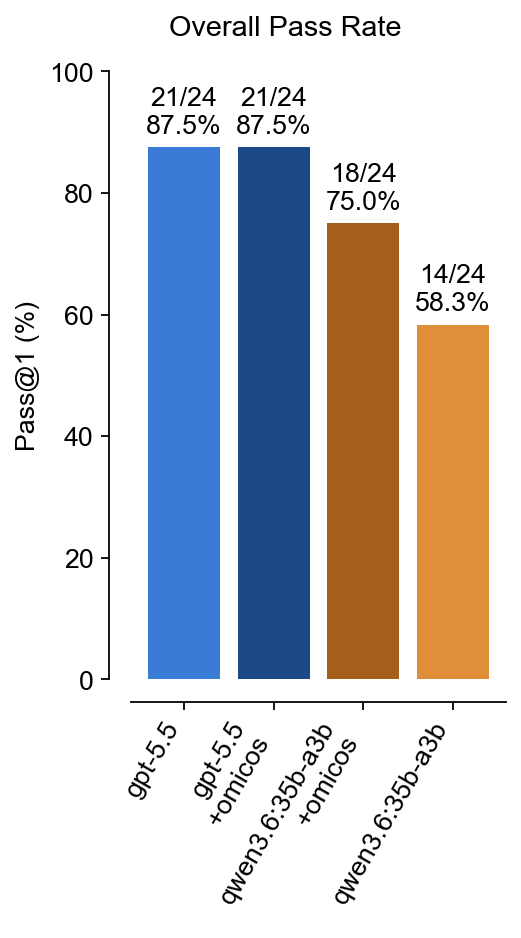

In [89]:
pass_overall = (df.groupby('arm_short')['passed_b']
                  .agg(['sum', 'count']).reset_index())
pass_overall['rate'] = pass_overall['sum'] / pass_overall['count']
pass_overall = pass_overall.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(3, 5))
colors = [ARM_PALETTE[a] for a in pass_overall['arm_short']]
bars = ax.bar(pass_overall['arm_short'], pass_overall['rate'] * 100, color=colors)
ax.set_ylabel('Pass@1 (%)')
ax.set_ylim(0, 100)
for b, n, c in zip(bars, pass_overall['sum'], pass_overall['count']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
            f'{n}/{c}\n{b.get_height():.1f}%',
            ha='center', va='bottom')
plt.suptitle('Overall Pass Rate',fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

plt.xticks(rotation=60, ha='right',fontsize=12)
#plt.tight_layout()
plt.savefig(FIGDIR / 'fig01_overall_pass.pdf',dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig01_overall_pass.svg',dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig01_overall_pass.png',dpi=300, bbox_inches='tight')
plt.show()

## 3. Per-layer × arm Pass@1 — heatmap

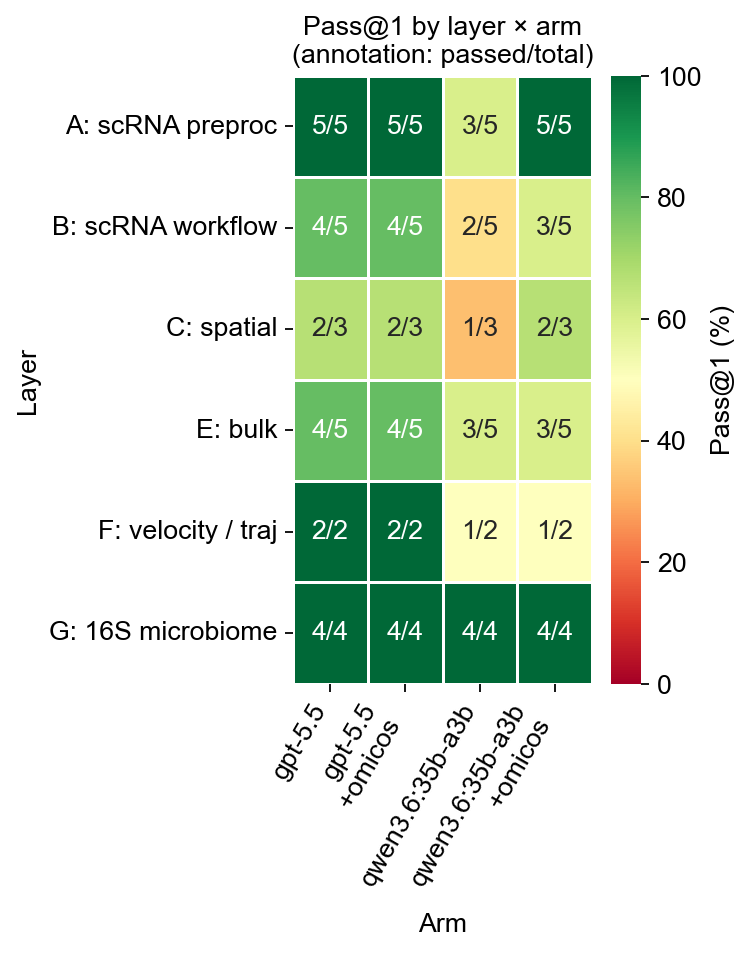

In [91]:
g = (df.groupby(['layer', 'arm_short'])['passed_b']
       .agg(['sum', 'count']).reset_index())
g['rate'] = g['sum'] / g['count']
heatmap = g.pivot(index='layer', columns='arm_short', values='rate')
annot = (g.assign(label=lambda x: x['sum'].astype(str)+'/'+x['count'].astype(str))
          .pivot(index='layer', columns='arm_short', values='label'))
heatmap = heatmap.reindex(columns=ordered_arms)
annot = annot.reindex(columns=ordered_arms)
heatmap.index = [LAYER_DESC.get(L, L) for L in heatmap.index]
annot.index = heatmap.index

fig, ax = plt.subplots(figsize=(3, 5))
sns.heatmap(heatmap*100, annot=annot, fmt='', cmap='RdYlGn',
            vmin=0, vmax=100, cbar_kws={'label': 'Pass@1 (%)'},
            linewidths=0.6, linecolor='white', ax=ax)
ax.set_xlabel('Arm')
ax.set_ylabel('Layer')
ax.set_title('Pass@1 by layer × arm\n(annotation: passed/total)')
plt.xticks(rotation=60, ha='right')
#plt.tight_layout()
plt.savefig(FIGDIR / 'fig02_layer_arm_heatmap.pdf',dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig02_layer_arm_heatmap.png',dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig02_layer_arm_heatmap.svg',dpi=300, bbox_inches='tight')
plt.show()

## 4. Per-task fractional score (24 tasks × 4 arms)

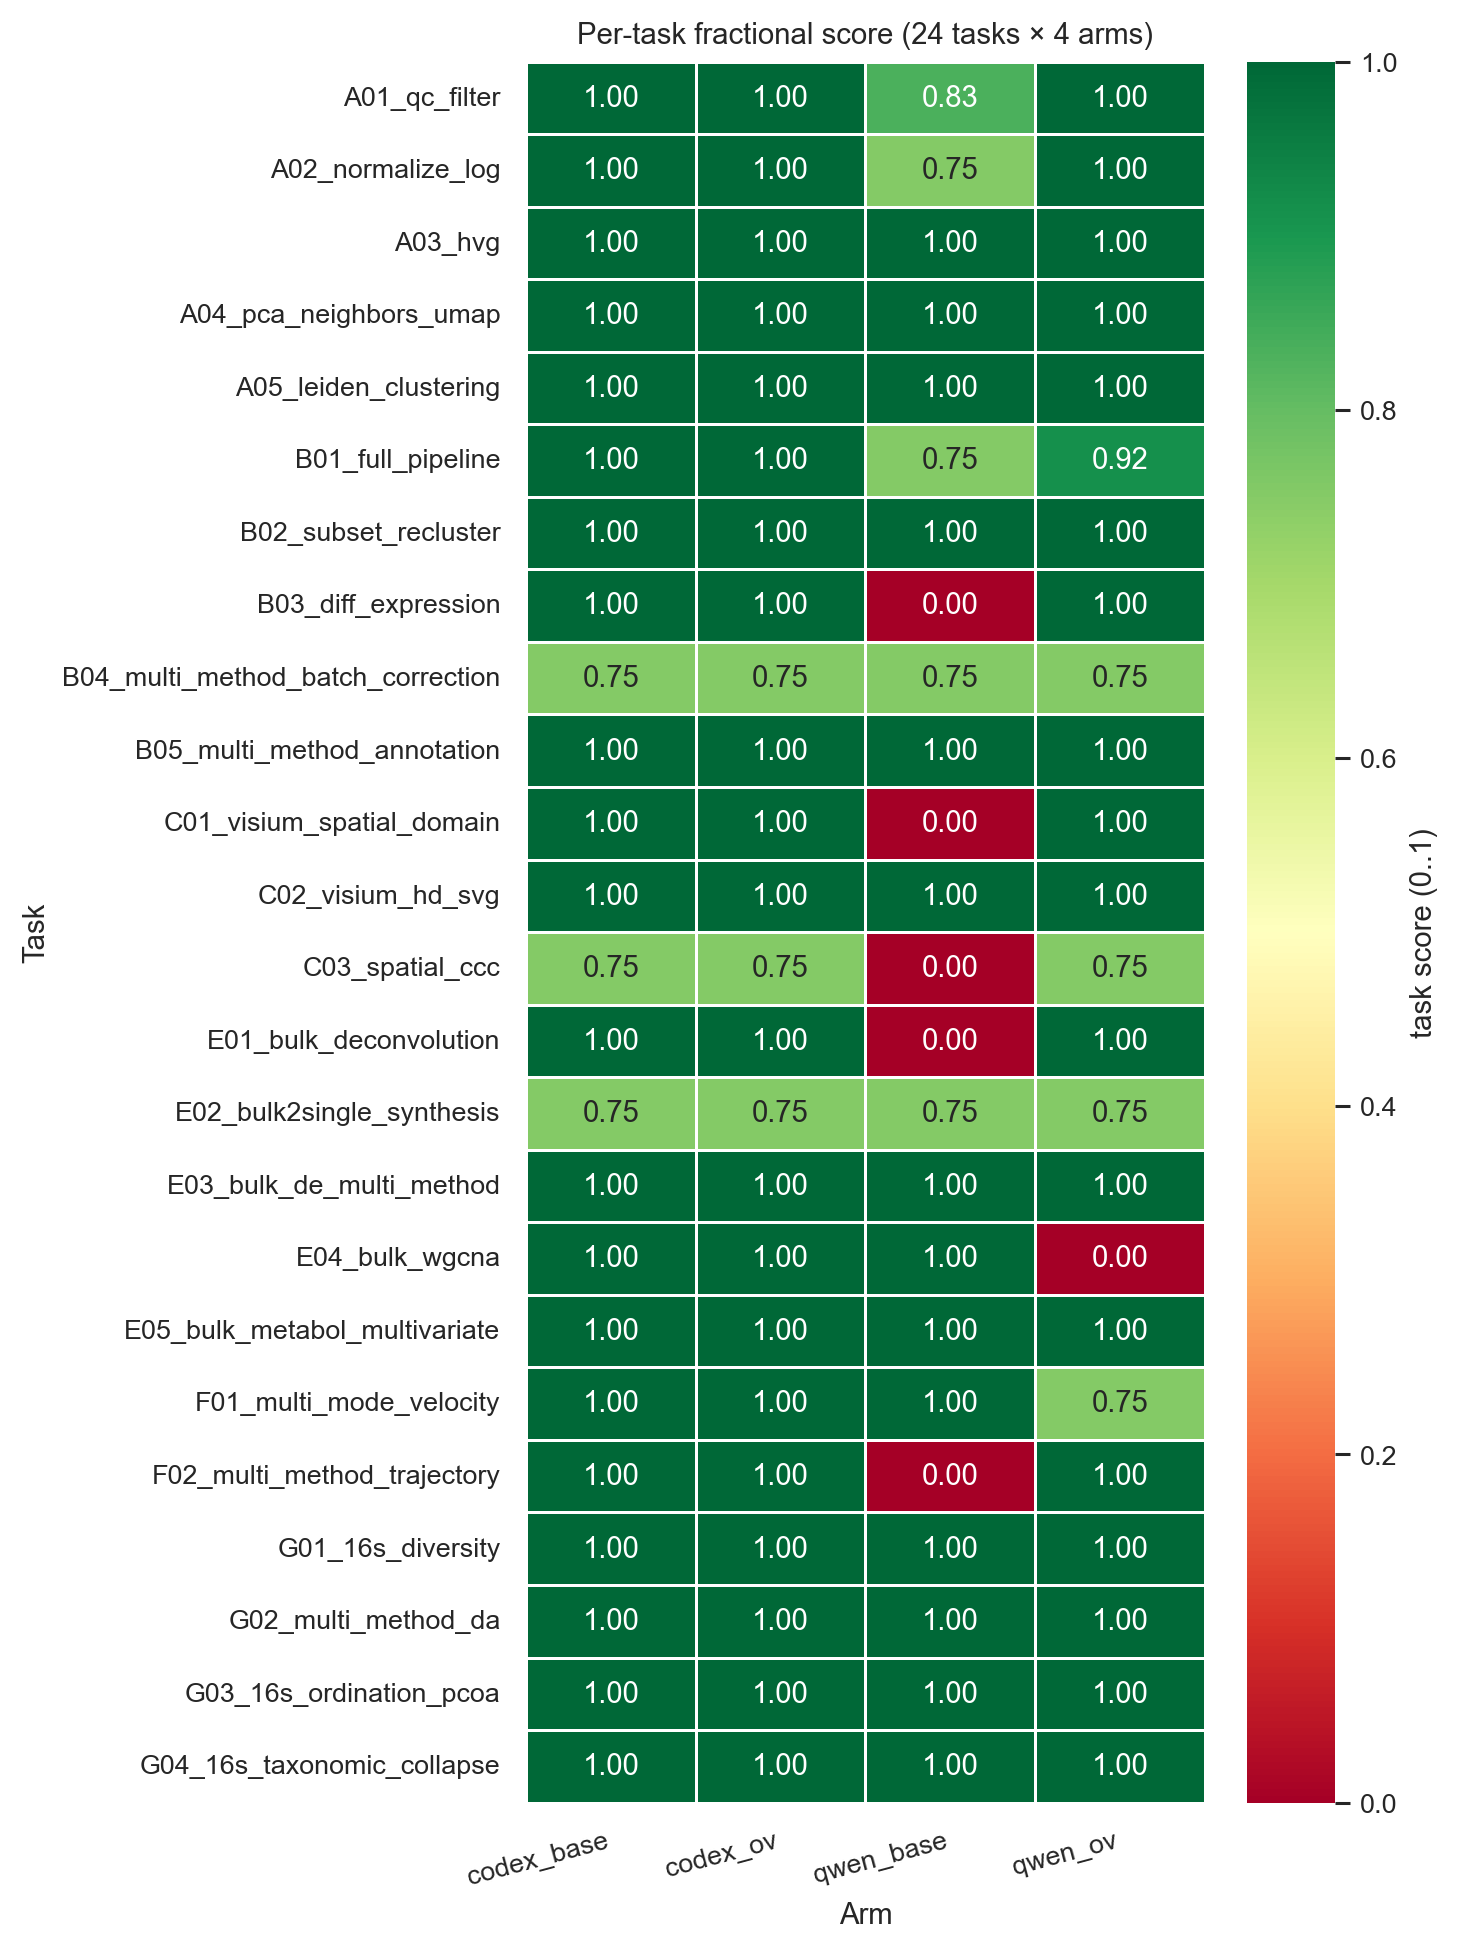

In [5]:
task_score = (df.pivot(index='task_id', columns='arm_short', values='score_f')
                .reindex(columns=ordered_arms)
                .sort_index())
fig, ax = plt.subplots(figsize=(6.5, 0.34*len(task_score)+0.8))
sns.heatmap(task_score, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'task score (0..1)'},
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_xlabel('Arm')
ax.set_ylabel('Task')
ax.set_title('Per-task fractional score (24 tasks × 4 arms)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig03_task_score_matrix.pdf')
plt.savefig(FIGDIR / 'fig03_task_score_matrix.png')
plt.show()

## 5. Per-check pass/fail matrix (~80 atomic rubric items × 4 arms)

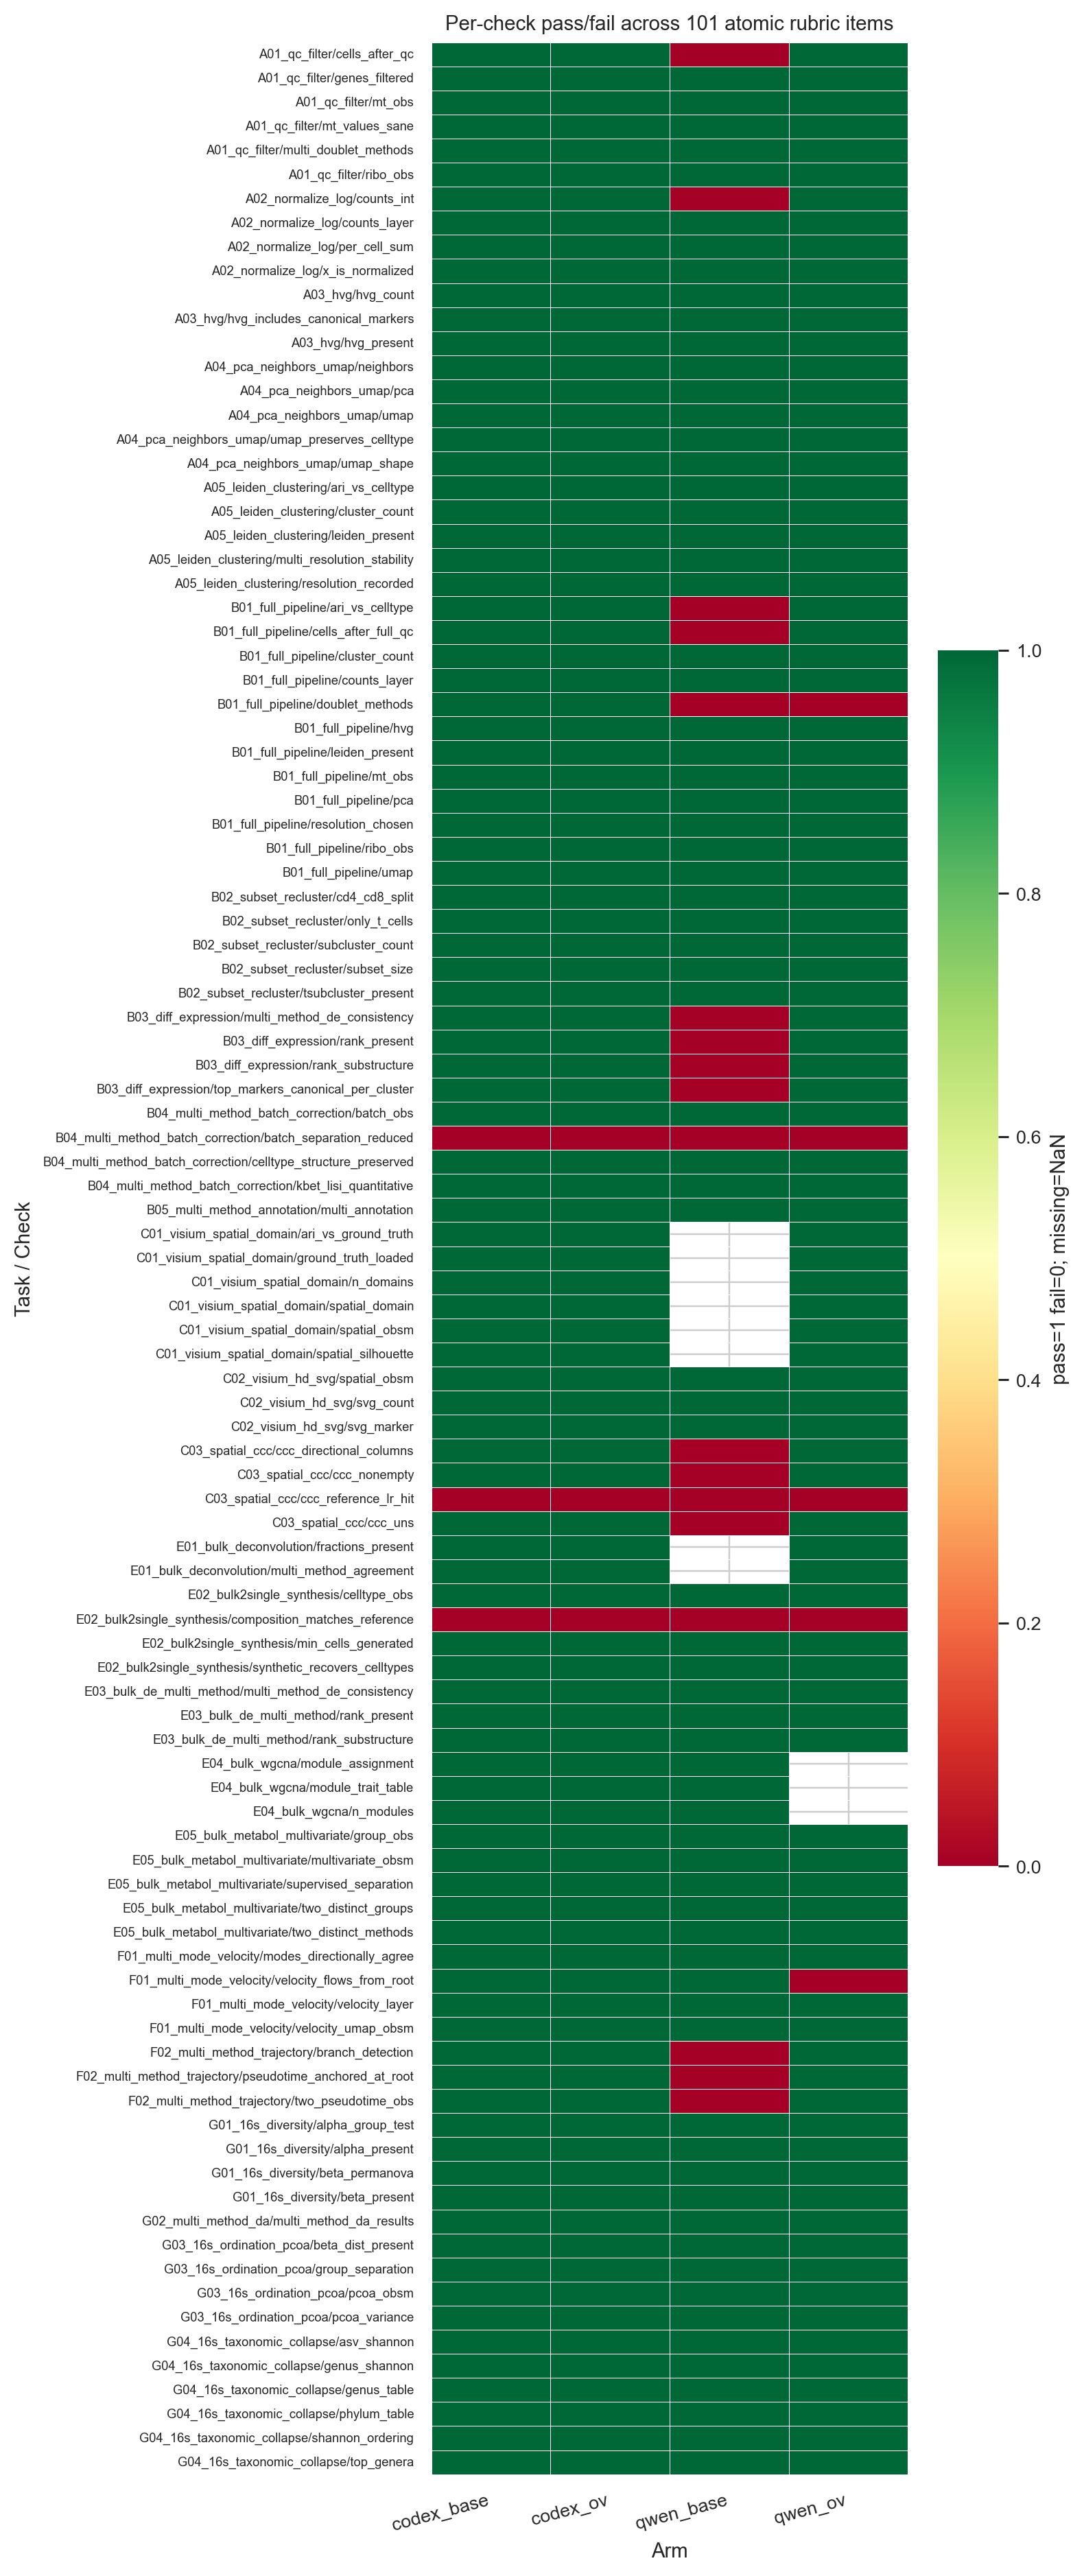

In [6]:
rec = []
for _, r in df.iterrows():
    try:
        rubric = json.loads(r['rubric_json'])
    except (TypeError, json.JSONDecodeError):
        continue
    for cid, p in rubric.items():
        rec.append({'task': r['task_id'], 'check': cid,
                    'arm': r['arm_short'], 'passed': bool(p)})
checks_df = pd.DataFrame(rec)
checks_df['task_check'] = checks_df['task'] + '/' + checks_df['check']
checks_mat = (checks_df.pivot(index='task_check', columns='arm', values='passed')
                       .astype(float)
                       .reindex(columns=ordered_arms)
                       .sort_index())

fig, ax = plt.subplots(figsize=(7.0, 0.16*len(checks_mat)+1))
sns.heatmap(checks_mat, cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'pass=1 fail=0; missing=NaN', 'shrink': 0.5},
            linewidths=0.2, linecolor='white', ax=ax)
ax.set_xlabel('Arm')
ax.set_ylabel('Task / Check')
ax.set_title(f'Per-check pass/fail across {len(checks_mat)} atomic rubric items')
plt.xticks(rotation=15, ha='right')
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig04_check_matrix.pdf')
plt.savefig(FIGDIR / 'fig04_check_matrix.png')
plt.show()

## 6. Per-check pass-rate per arm — bar

Two flavours:

* **a)** Each task's check pass-rate (mean fraction of its rubric items that pass), grouped by arm — finer-grained than overall task Pass@1
* **b)** Per-arm overall check pass-rate (out of all ~80 atomic checks): captures "sub-task quality" beyond all-or-nothing task gates

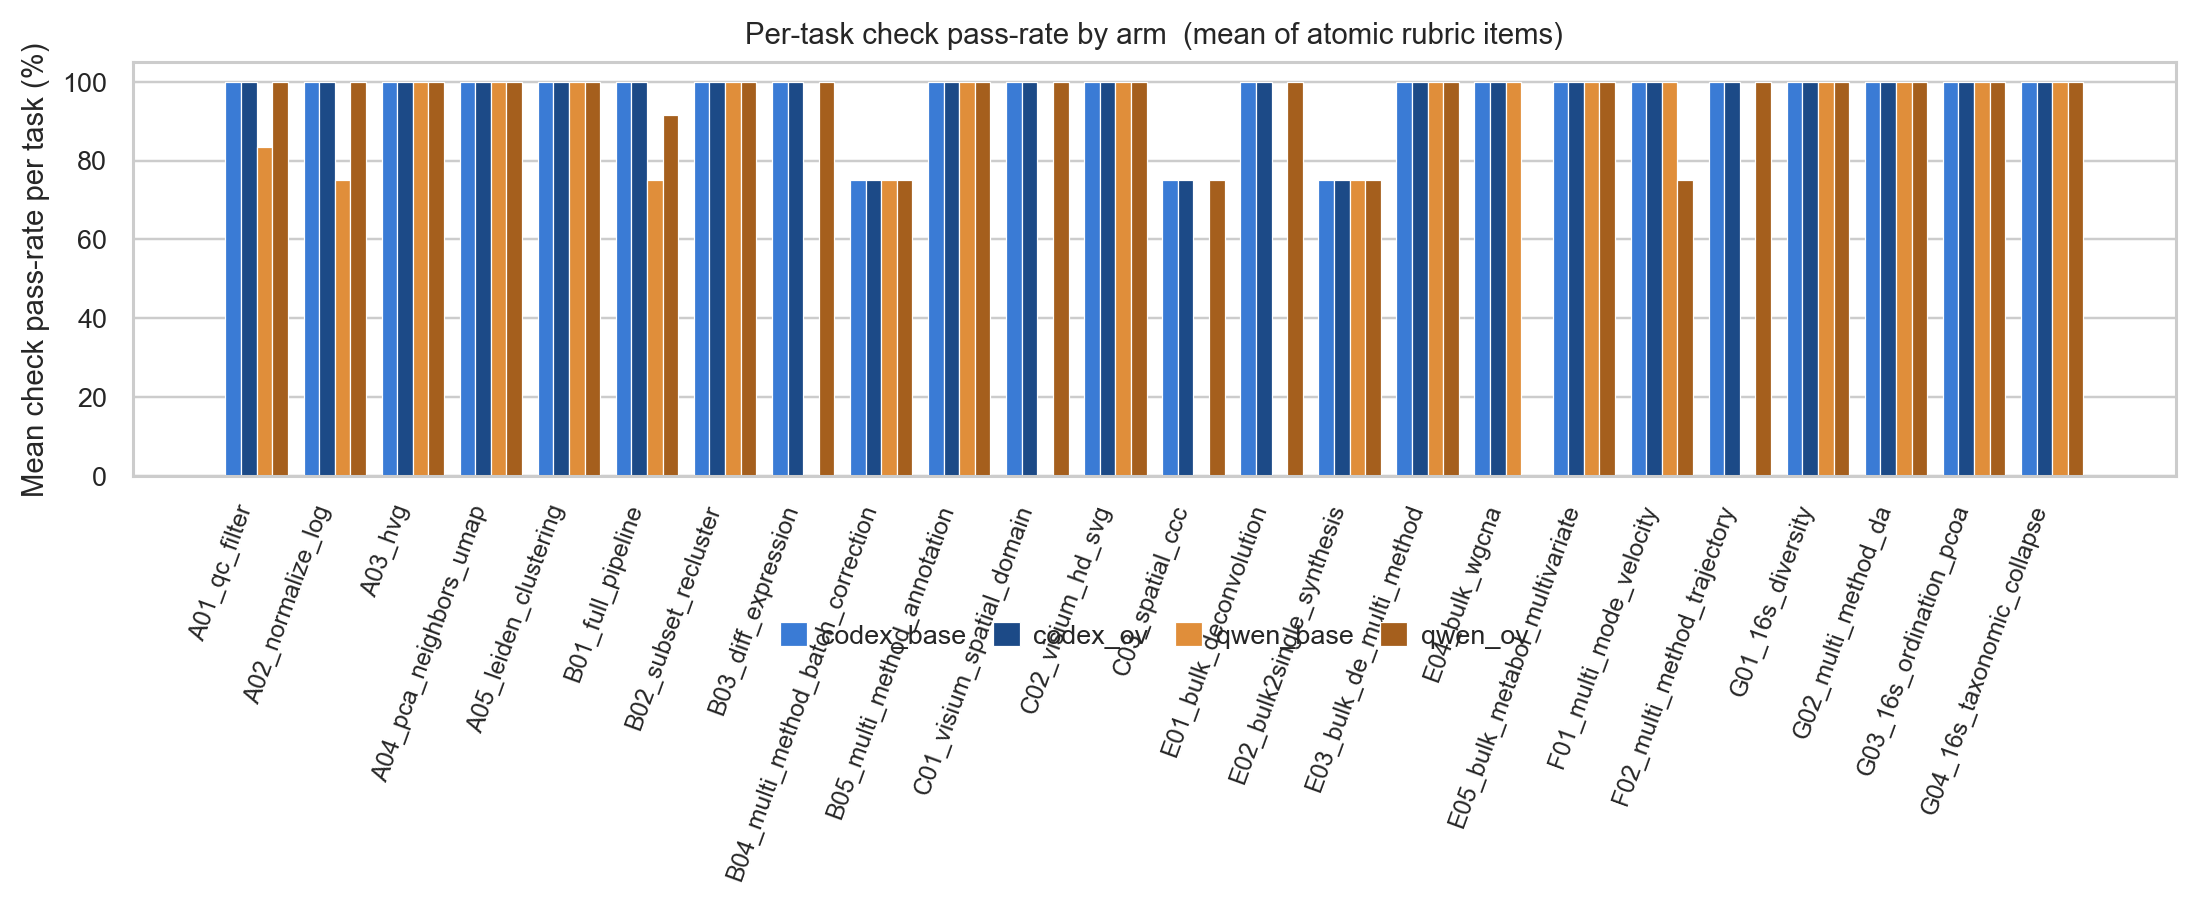

In [7]:
# (a) Per-task average check pass-rate per arm — grouped bars by task,
#     coloured by arm.
task_check_rate = (checks_df.groupby(['task','arm'])['passed']
                              .mean().reset_index()
                              .pivot(index='task', columns='arm', values='passed')
                              .reindex(columns=ordered_arms)
                              .sort_index())
n_tasks = len(task_check_rate)
x = np.arange(n_tasks)
w = 0.20
fig, ax = plt.subplots(figsize=(max(8, 0.42*n_tasks), 4.2))
for i, a in enumerate(ordered_arms):
    offset = (i - (len(ordered_arms)-1)/2) * w
    ax.bar(x + offset, task_check_rate[a].fillna(0)*100, width=w,
           color=ARM_PALETTE[a], label=a, edgecolor='white', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(task_check_rate.index, rotation=70, ha='right', fontsize=8)
ax.set_ylabel('Mean check pass-rate per task (%)')
ax.set_ylim(0, 105)
ax.set_title('Per-task check pass-rate by arm  (mean of atomic rubric items)')
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.32))
ax.grid(axis='x', alpha=0)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig05a_per_task_check_rate.pdf')
plt.savefig(FIGDIR / 'fig05a_per_task_check_rate.png')
plt.show()

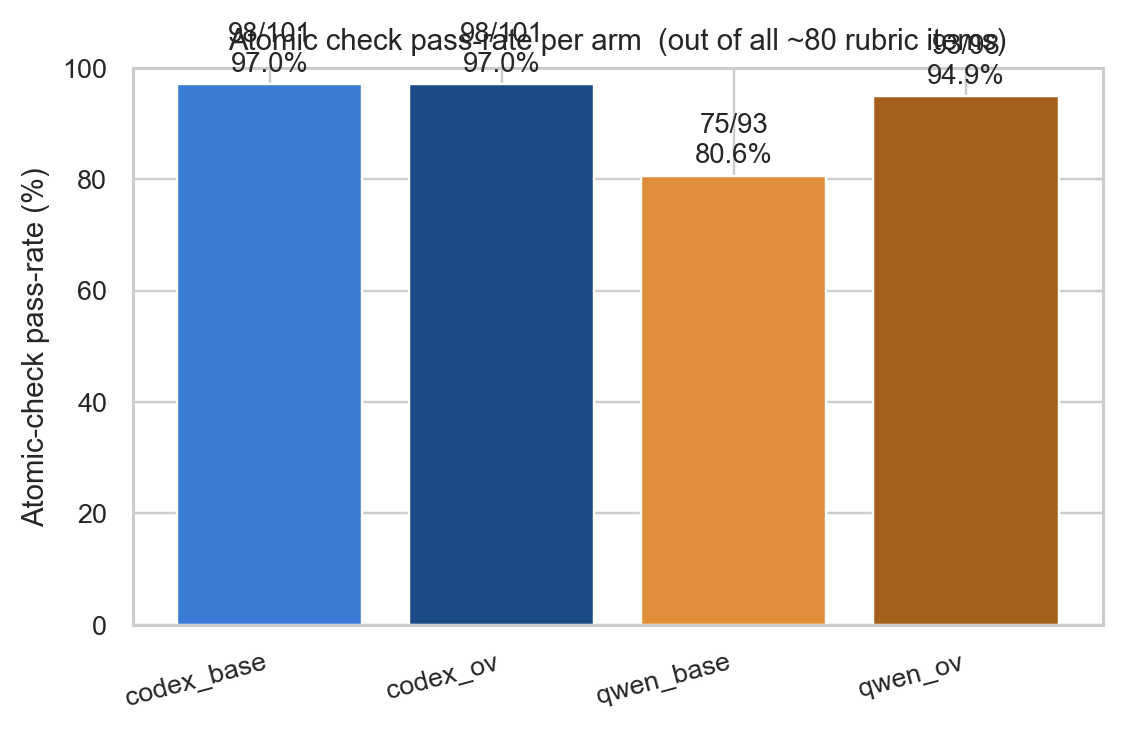

In [8]:
# (b) Per-arm overall check pass-rate: how many of all atomic checks
#     pass per arm. Robust to all-or-nothing task framing.
arm_check_rate = (checks_df.groupby('arm')['passed']
                            .agg(['sum', 'count'])
                            .reindex(ordered_arms))
arm_check_rate['rate'] = arm_check_rate['sum'] / arm_check_rate['count']
fig, ax = plt.subplots(figsize=(5.2, 3.4))
colors = [ARM_PALETTE[a] for a in arm_check_rate.index]
bars = ax.bar(arm_check_rate.index, arm_check_rate['rate']*100, color=colors)
ax.set_ylabel('Atomic-check pass-rate (%)')
ax.set_ylim(0, 100)
for b, n, c in zip(bars, arm_check_rate['sum'], arm_check_rate['count']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2,
            f'{n}/{c}\n{b.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Atomic check pass-rate per arm  (out of all ~80 rubric items)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig05b_overall_check_rate.pdf')
plt.savefig(FIGDIR / 'fig05b_overall_check_rate.png')
plt.show()

## 7. Within-model: omicverse vs baseline pass-rate uplift

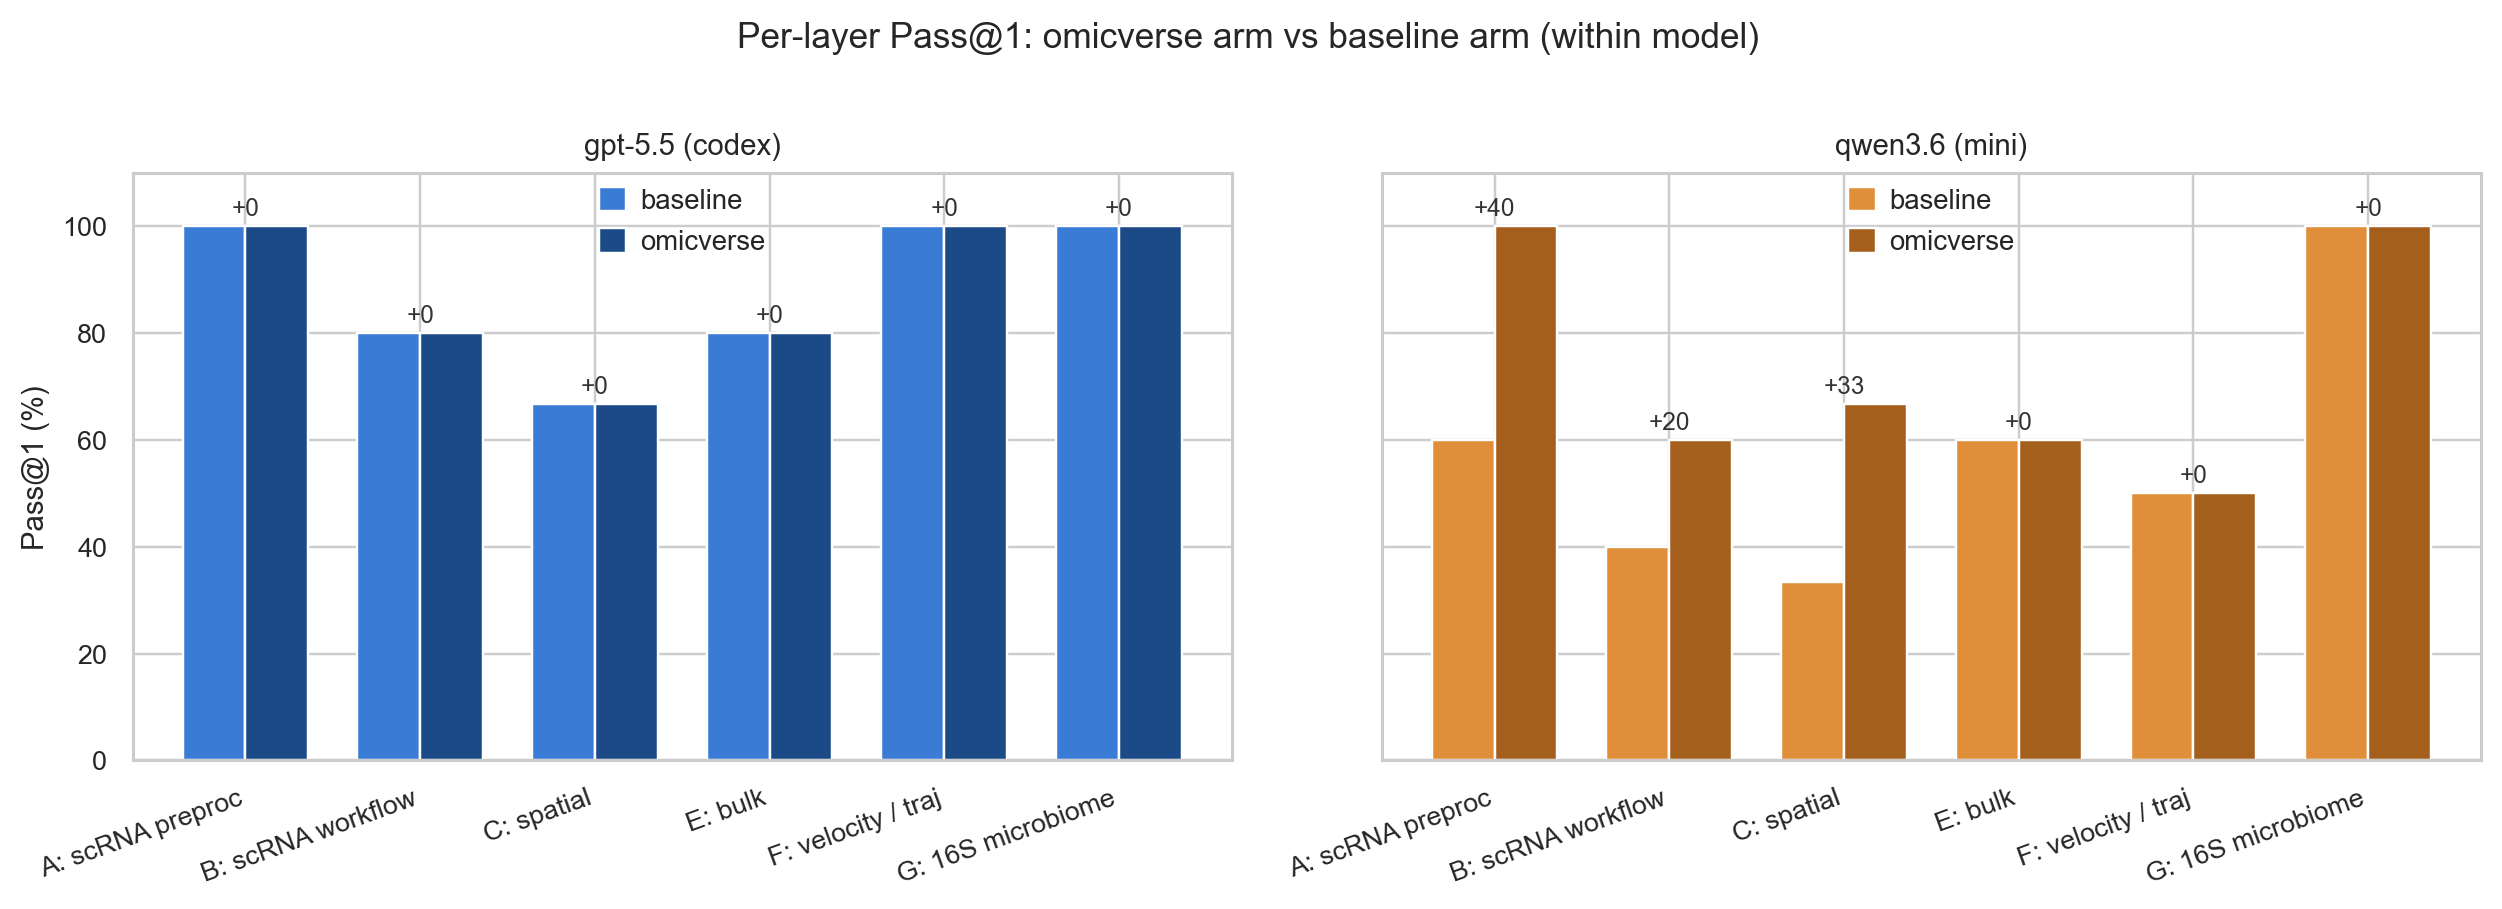

In [9]:
uplift_rows = []
for model_label, base, ov_arm in [
    ('gpt-5.5', 'gpt_base', 'gpt_ov'),
    ('qwen3.6 (mini)', 'qwen_base', 'qwen_ov'),
]:
    for layer in sorted(df['layer'].unique()):
        sub = df[df['layer']==layer]
        b = sub[sub['arm_short']==base]['passed_b'].mean()
        o = sub[sub['arm_short']==ov_arm]['passed_b'].mean()
        if pd.isna(b) or pd.isna(o): continue
        uplift_rows.append({'model': model_label, 'layer': LAYER_DESC.get(layer, layer),
                            'baseline': b*100, 'omicverse': o*100,
                            'uplift': (o-b)*100})
uplift = pd.DataFrame(uplift_rows)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), sharey=True)
for ax, (model_label, sub) in zip(axes, uplift.groupby('model')):
    sub = sub.sort_values('layer')
    x = np.arange(len(sub))
    w = 0.36
    base_color = ARM_PALETTE['gpt_base'] if 'gpt' in model_label else ARM_PALETTE['qwen_base']
    ov_color   = ARM_PALETTE['gpt_ov']   if 'gpt' in model_label else ARM_PALETTE['qwen_ov']
    ax.bar(x - w/2, sub['baseline'], width=w, color=base_color, label='baseline')
    ax.bar(x + w/2, sub['omicverse'], width=w, color=ov_color, label='omicverse')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['layer'], rotation=20, ha='right')
    ax.set_title(model_label)
    ax.set_ylim(0, 110)
    ax.set_ylabel('Pass@1 (%)' if ax is axes[0] else '')
    ax.legend(frameon=False, fontsize=9)
    for xi, (_, row) in zip(x, sub.iterrows()):
        ax.annotate(f'{row["uplift"]:+.0f}',
                    xy=(xi, max(row['baseline'], row['omicverse'])+2),
                    ha='center', fontsize=8, color='#333')
fig.suptitle('Per-layer Pass@1: omicverse arm vs baseline arm (within model)', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig06_within_model_uplift.pdf')
plt.savefig(FIGDIR / 'fig06_within_model_uplift.png')
plt.show()

## 8. Quantitative metric extraction

Pulls a single representative numeric per (task, check, arm) from the grader notes.

In [10]:
NUM_PATTERNS = [
    ('outward_cosine', re.compile(r'outward cosine\s*=\s*(-?\d+\.\d+)', re.I)),
    ('mean_cosine',    re.compile(r'mean cosine\s*=\s*(-?\d+\.\d+)', re.I)),
    ('ARI',            re.compile(r'\bARI\s*=\s*(-?\d+\.\d+)', re.I)),
    ('silhouette',     re.compile(r'silhouette[^=]*=\s*(-?\d+\.\d+)', re.I)),
    ('Jaccard',        re.compile(r'Jaccard[^=]*=\s*(-?\d+\.\d+)', re.I)),
    ('correlation',    re.compile(r'correlation[^=]*=\s*(-?\d+\.\d+)', re.I)),
    ('agreement',      re.compile(r'agreement[^=]*=\s*(-?\d+\.\d+)', re.I)),
    ('improvement',    re.compile(r'improvement[^=]*=\s*(\+?-?\d+\.\d+)', re.I)),
    ('drop',           re.compile(r'drop\s*=\s*(\+?-?\d+\.\d+)', re.I)),
]

def split_notes(notes):
    out = {}
    for chunk in (notes or '').split(' | '):
        if ':' in chunk:
            cid, _, msg = chunk.partition(':')
            out[cid.strip()] = msg.strip()
    return out

def extract(msg):
    for label, pat in NUM_PATTERNS:
        m = pat.search(msg)
        if m:
            try:
                return label, float(m.group(1))
            except ValueError:
                pass
    return None, None

metric_rows = []
for _, r in df.iterrows():
    nb = split_notes(r['notes'])
    for cid, msg in nb.items():
        label, val = extract(msg)
        if label is None: continue
        metric_rows.append({'task': r['task_id'], 'layer': r['layer'],
                            'check': cid, 'arm': r['arm_short'],
                            'metric': label, 'value': val,
                            'passed': r['passed_b']})
metrics = pd.DataFrame(metric_rows)
metrics.head()

,task,layer,check,arm,metric,value,passed
0,A05_leiden_clustering,A,multi_resolution_stability,gpt_base,ARI,0.621,True
1,A05_leiden_clustering,A,ari_vs_celltype,gpt_base,ARI,0.924,True
2,A05_leiden_clustering,A,multi_resolution_stability,gpt_ov,ARI,0.650,True
3,A05_leiden_clustering,A,ari_vs_celltype,gpt_ov,ARI,0.879,True
4,B01_full_pipeline,B,ari_vs_celltype,gpt_base,ARI,0.473,True


## 9. Metric-family distribution per arm (boxplot + strip)

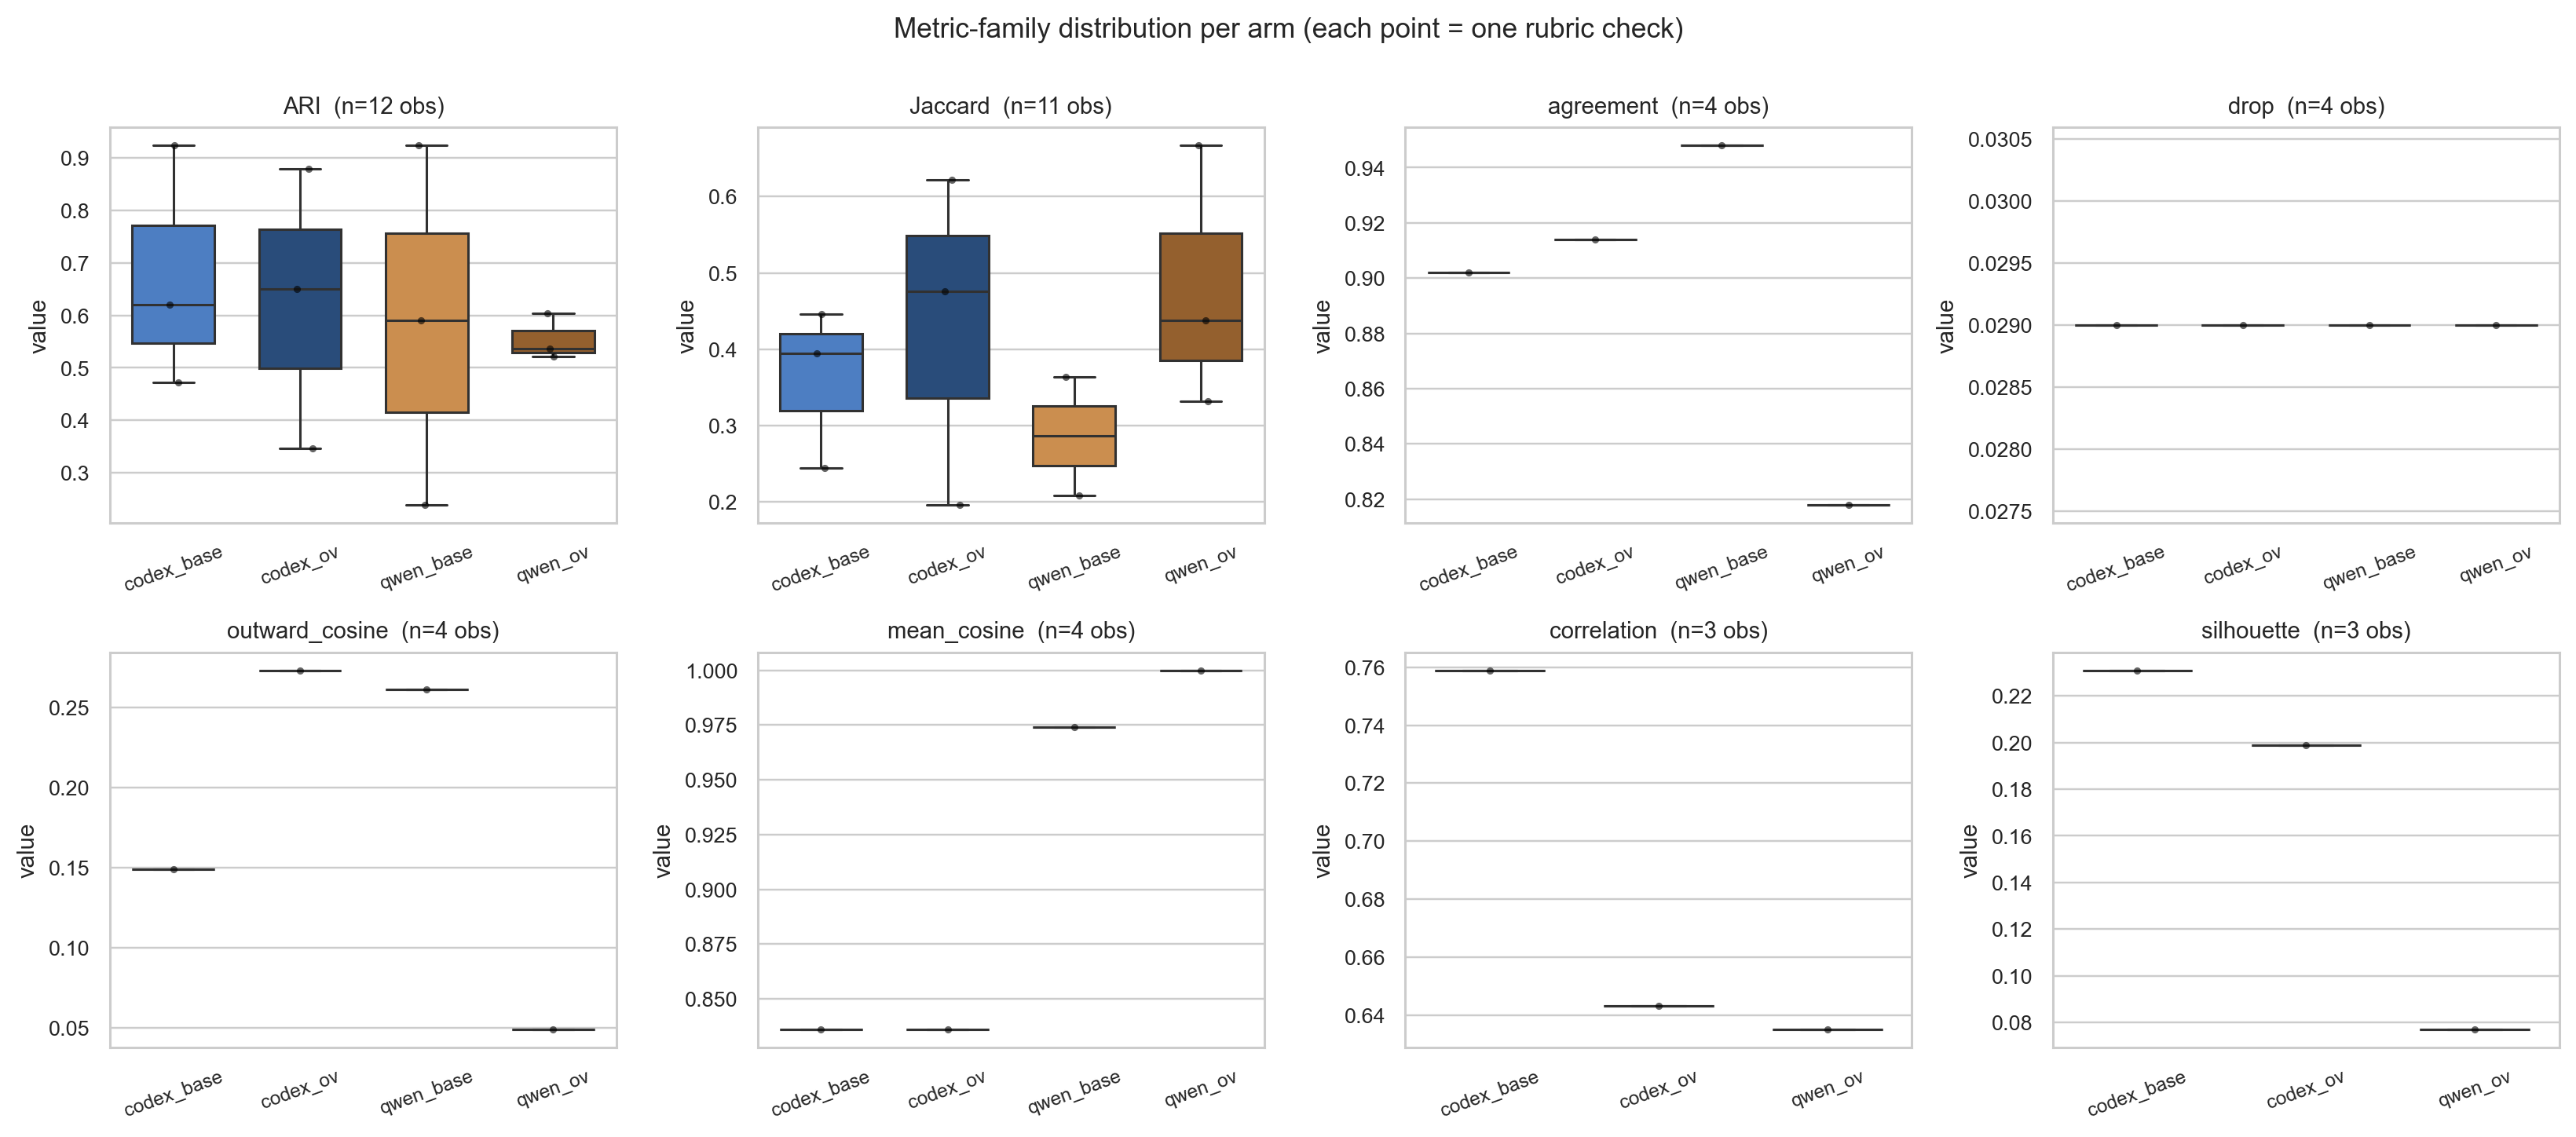

In [11]:
metric_order = (metrics.groupby('metric').size().sort_values(ascending=False)
                  .head(8).index.tolist())
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharey=False)
for ax, m in zip(axes.flat, metric_order):
    sub = metrics[metrics['metric']==m]
    arms_present = [a for a in ordered_arms if a in sub['arm'].unique()]
    pal = [ARM_PALETTE[a] for a in arms_present]
    sns.boxplot(data=sub, x='arm', y='value', order=arms_present, palette=pal,
                ax=ax, fliersize=0, width=0.65)
    sns.stripplot(data=sub, x='arm', y='value', order=arms_present,
                  color='black', size=3.0, alpha=0.6, ax=ax)
    ax.set_title(f'{m}  (n={len(sub)} obs)')
    ax.set_xlabel('')
    ax.set_ylabel('value')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
for ax in axes.flat[len(metric_order):]:
    ax.set_visible(False)
fig.suptitle('Metric-family distribution per arm (each point = one rubric check)', y=1.005)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig07_metric_distribution.pdf')
plt.savefig(FIGDIR / 'fig07_metric_distribution.png')
plt.show()

## 10. Head-to-head: 4-arm scores on every diverging quantitative check

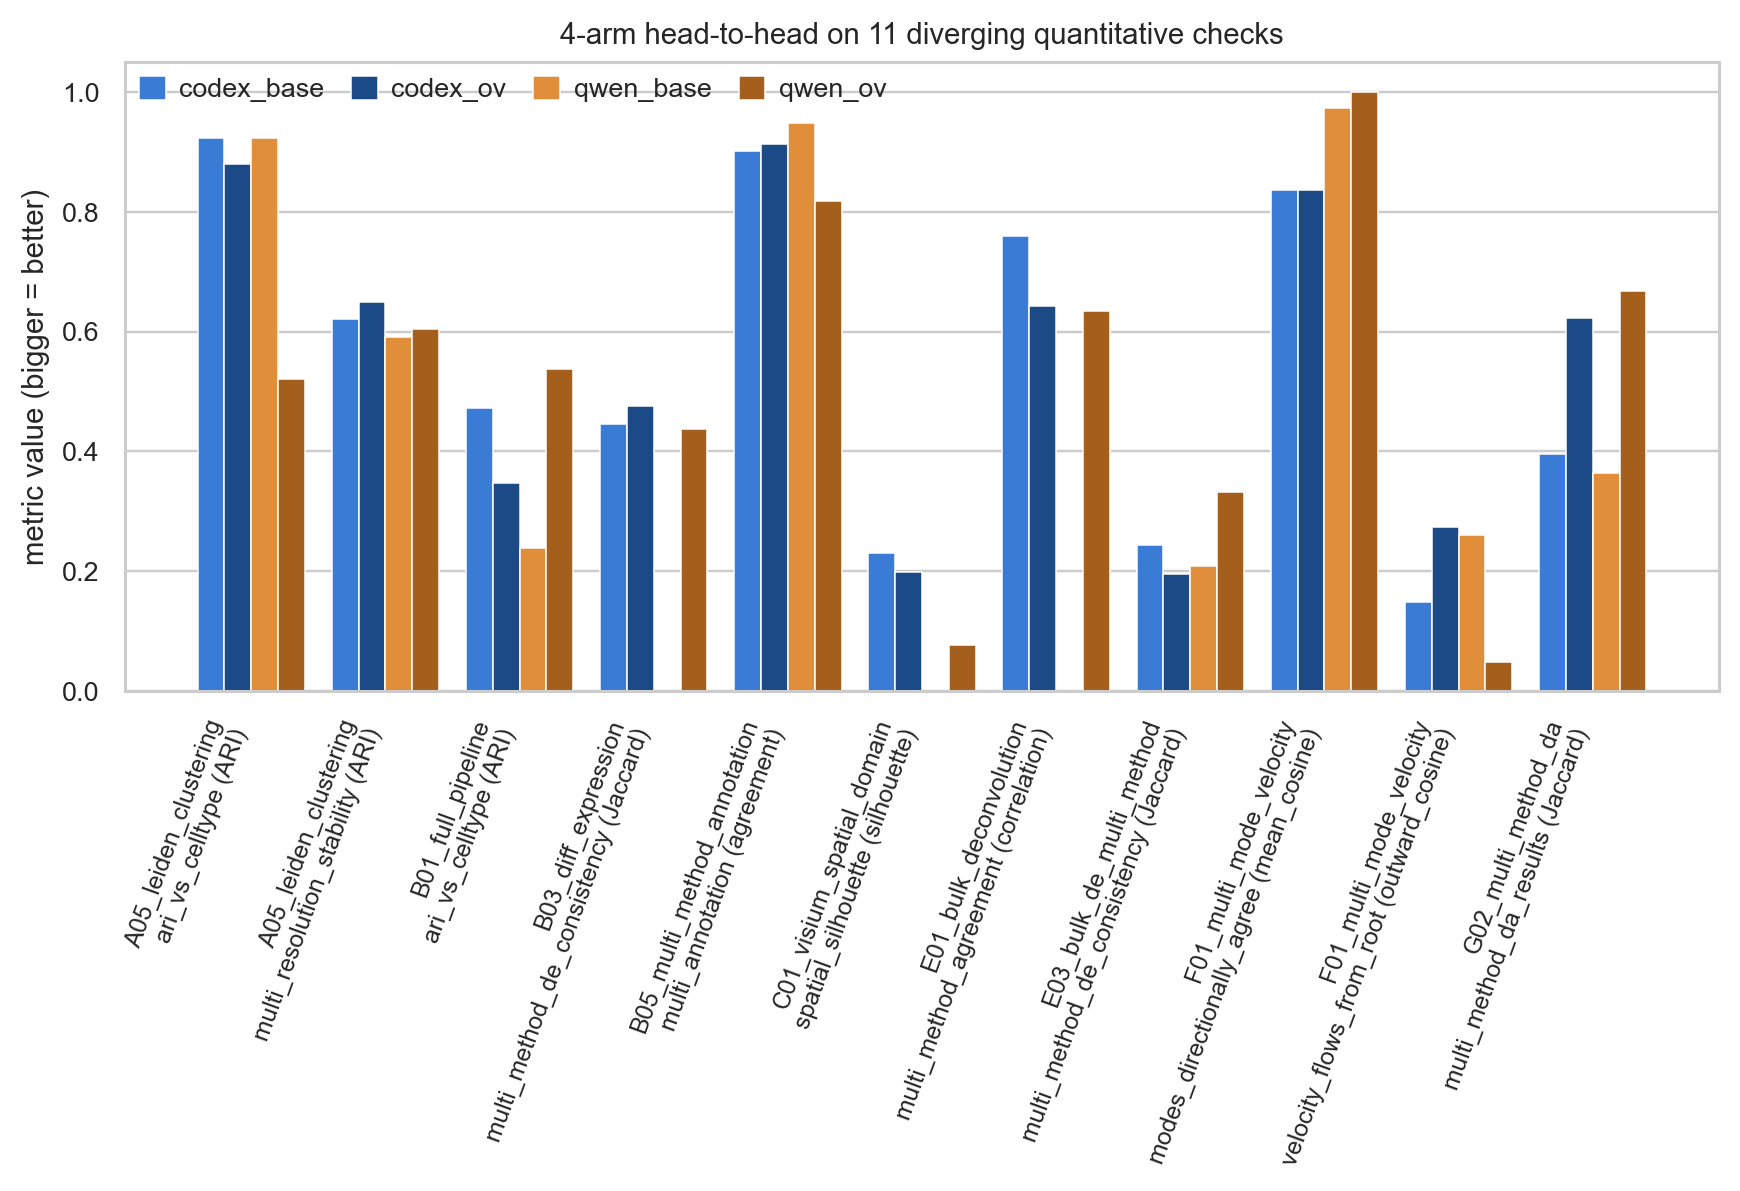

In [12]:
wide = (metrics.pivot_table(index=['task','check','metric'], columns='arm', values='value')
                 .reindex(columns=ordered_arms))
wide = wide.dropna(thresh=2)
tolerance = 0.001
diverging = wide[(wide.max(axis=1) - wide.min(axis=1)) > tolerance].copy()
diverging['label'] = (diverging.index.get_level_values('task') + '\n' +
                       diverging.index.get_level_values('check') +
                       ' (' + diverging.index.get_level_values('metric') + ')')

n = len(diverging)
x = np.arange(n)
w = 0.20
fig, ax = plt.subplots(figsize=(max(8, 0.65*n), 5.5))
for i, a in enumerate(ordered_arms):
    if a not in diverging.columns: continue
    offset = (i - (len(ordered_arms)-1)/2) * w
    ax.bar(x + offset, diverging[a].fillna(0), width=w, color=ARM_PALETTE[a],
           label=a, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(diverging['label'], rotation=70, ha='right', fontsize=8)
ax.set_ylabel('metric value (bigger = better)')
ax.set_title(f'4-arm head-to-head on {n} diverging quantitative checks')
ax.legend(frameon=False, ncol=4, loc='upper left')
ax.grid(axis='x', alpha=0)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig08_head_to_head.pdf')
plt.savefig(FIGDIR / 'fig08_head_to_head.png')
plt.show()

## 11. Within-model omicverse − baseline metric delta

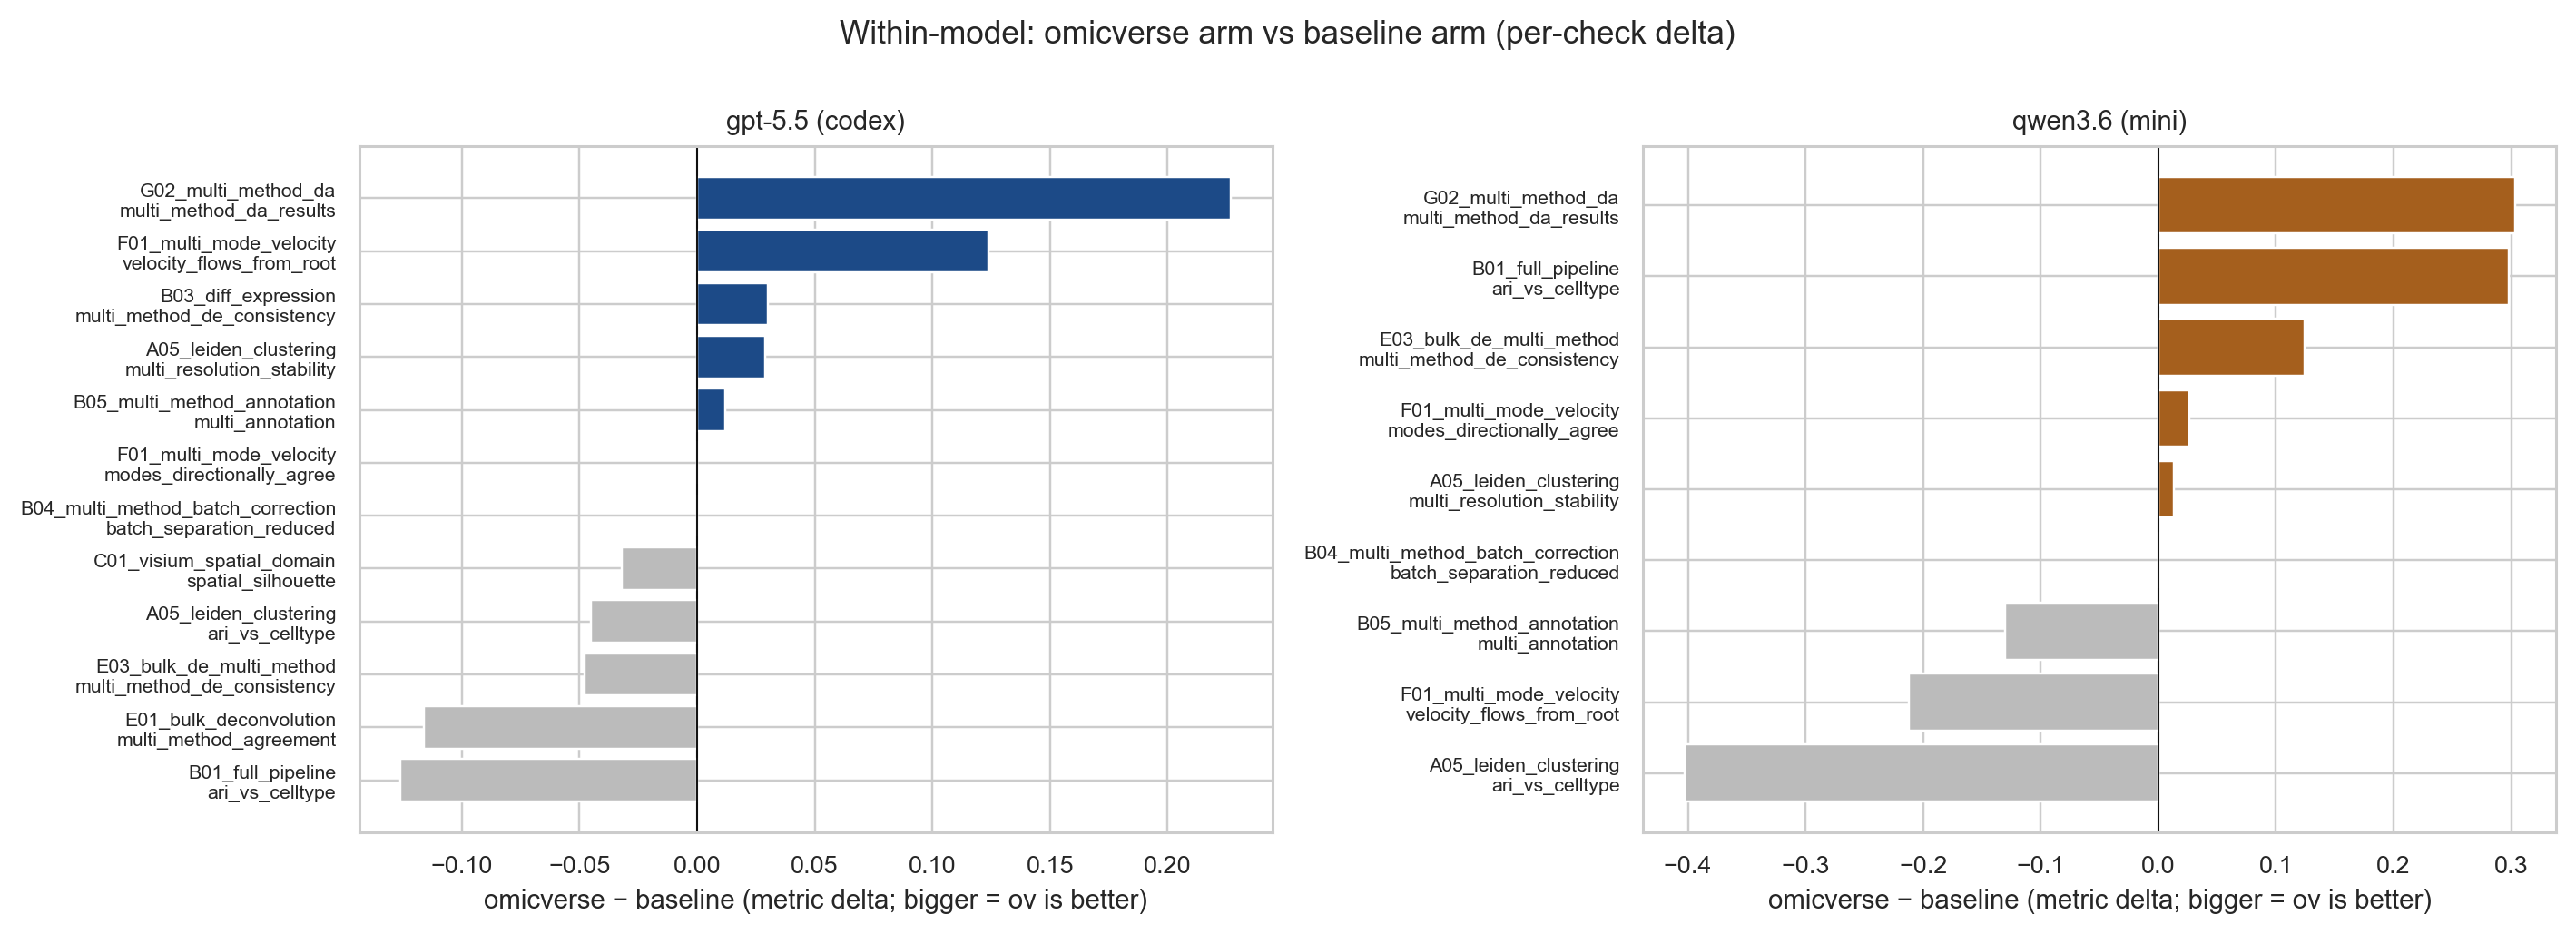

In [13]:
delta_rows = []
for (task, check, metric), row in wide.iterrows():
    for model_label, base, ov_arm in [
        ('gpt-5.5', 'gpt_base', 'gpt_ov'),
        ('qwen3.6 (mini)',  'qwen_base',  'qwen_ov'),
    ]:
        if base in row.index and ov_arm in row.index and not pd.isna(row[base]) and not pd.isna(row[ov_arm]):
            delta = row[ov_arm] - row[base]
            delta_rows.append({'task': task, 'check': check, 'metric': metric,
                               'model': model_label, 'delta': delta})
delta_df = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (model_label, sub) in zip(axes, delta_df.groupby('model')):
    sub = sub.sort_values('delta')
    pos_color = ARM_PALETTE['gpt_ov'] if 'gpt' in model_label else ARM_PALETTE['qwen_ov']
    color = sub['delta'].apply(lambda d: pos_color if d >= 0 else '#bbbbbb')
    labels = sub['task'] + '\n' + sub['check']
    ax.barh(np.arange(len(sub)), sub['delta'], color=color)
    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_xlabel('omicverse − baseline (metric delta; bigger = ov is better)')
    ax.set_title(model_label)
fig.suptitle('Within-model: omicverse arm vs baseline arm (per-check delta)', y=1.005)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig09_within_model_delta.pdf')
plt.savefig(FIGDIR / 'fig09_within_model_delta.png')
plt.show()

## 12. Failure-mode taxonomy

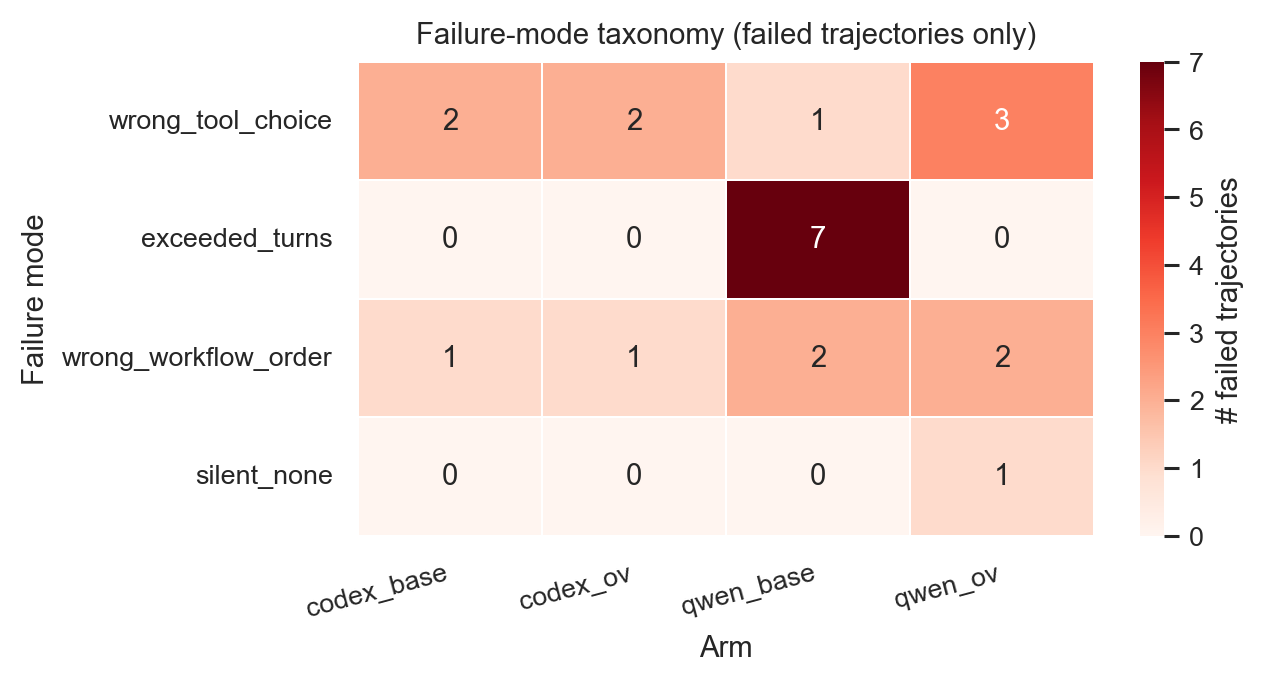

In [14]:
fm = (df[~df['passed_b']].groupby(['arm_short', 'failure_mode'])
        .size().reset_index(name='count'))
fm_mat = (fm.pivot(index='failure_mode', columns='arm_short', values='count')
             .fillna(0).astype(int)
             .reindex(columns=ordered_arms))
fm_mat = fm_mat.loc[fm_mat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(6.0, 0.45*len(fm_mat)+1.4))
sns.heatmap(fm_mat, annot=True, fmt='d', cmap='Reds',
            cbar_kws={'label': '# failed trajectories'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_xlabel('Arm')
ax.set_ylabel('Failure mode')
ax.set_title('Failure-mode taxonomy (failed trajectories only)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig10_failure_modes.pdf')
plt.savefig(FIGDIR / 'fig10_failure_modes.png')
plt.show()

## 13. Wallclock × turns scatter (efficiency)

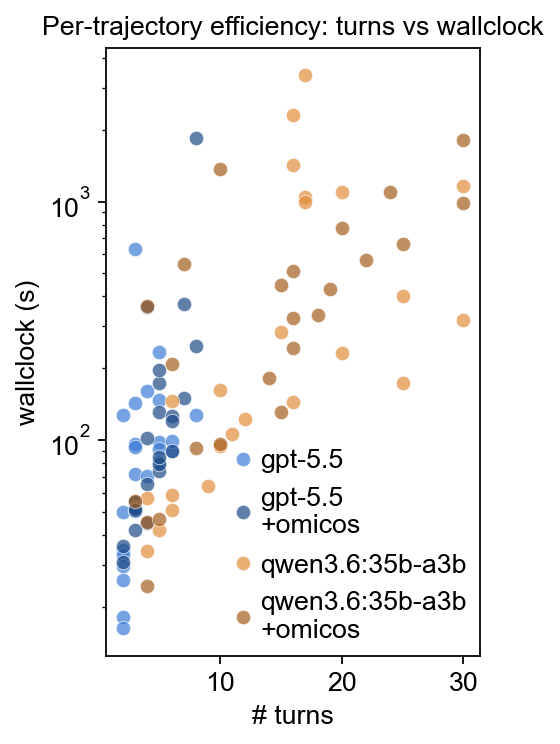

In [87]:
eff = df[df['n_turns_i'].notna() & df['wallclock_f'].notna() &
          (df['n_turns_i'] > 0)].copy()
fig, ax = plt.subplots(figsize=(3, 5))
for arm, sub in eff.groupby('arm_short'):
    ax.scatter(sub['n_turns_i'], sub['wallclock_f'],
               c=ARM_PALETTE[arm], s=42, alpha=0.7, label=arm,
               edgecolors='white', linewidths=0.4)
ax.set_xlabel('# turns')
ax.set_ylabel('wallclock (s)')
ax.set_yscale('log')
ax.set_title('Per-trajectory efficiency: turns vs wallclock')
ax.legend(frameon=False, fontsize=12)
#plt.tight_layout()
plt.savefig(FIGDIR / 'fig11_efficiency.pdf',dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig11_efficiency.png',dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig11_efficiency.svg',dpi=300, bbox_inches='tight')
plt.show()

## 14. Summary table — for camera-ready

In [16]:
layer_table = heatmap.copy() * 100
overall_row = pass_overall.set_index('arm_short')['rate'].reindex(ordered_arms)*100
summary = pd.concat([layer_table, overall_row.to_frame('Overall').T])
summary = summary.round(1)
summary.to_csv(FIGDIR / 'summary_pass_at_1.csv')
summary

arm_short,gpt_base,gpt_ov,qwen_base,qwen_ov
A: scRNA preproc,100.0,100.0,60.0,100.0
B: scRNA workflow,80.0,80.0,40.0,60.0
C: spatial,66.7,66.7,33.3,66.7
E: bulk,80.0,80.0,60.0,60.0
F: velocity / traj,100.0,100.0,50.0,50.0
G: 16S microbiome,100.0,100.0,100.0,100.0
Overall,87.5,87.5,58.3,75.0


In [17]:
for f in sorted(FIGDIR.iterdir()):
    print(f.name)

fig01_overall_pass.pdf
fig01_overall_pass.png
fig02_layer_arm_heatmap.pdf
fig02_layer_arm_heatmap.png
fig03_task_score_matrix.pdf
fig03_task_score_matrix.png
fig04_check_matrix.pdf
fig04_check_matrix.png
fig05a_per_task_check_rate.pdf
fig05a_per_task_check_rate.png
fig05b_overall_check_rate.pdf
fig05b_overall_check_rate.png
fig06_within_model_uplift.pdf
fig06_within_model_uplift.png
fig07_metric_distribution.pdf
fig07_metric_distribution.png
fig08_head_to_head.pdf
fig08_head_to_head.png
fig09_within_model_delta.pdf
fig09_within_model_delta.png
fig10_failure_modes.pdf
fig10_failure_modes.png
fig11_efficiency.pdf
fig11_efficiency.png
summary_pass_at_1.csv
